# The river flows, the water never stays the same
FX and Quantitative Research Issue #1<br>12 September 2025

Dominik Mueller (dominik.mueller@metzler.com)
<br><small>*Head of Currency Management at Metzler Capital Markets<br>https://www.metzler.com/en/metzler/capital-markets/currency-management*</small>

### Abstract
This research article examines volatility as a measure of risk, using the US dollar and the dollar index (DXY) as a motivating example. The article has two parts: a classification of current currency market events in historical context and a technical explanation of how exchange rate fluctuations are measured and modelled. The conclusion highlights why these insights are crucial for investors, asset managers, and risk managers.

### The role of the US dollar from Bretton Woods to today
The orthogonality of today's events to the past is striking. While the then member states of the newly founded International Monetary Fund (IMF) met in **Bretton Woods** in New Hampshire in 1944 to avoid the mistakes that were made after the First World War and, according to current estimates, contributed to the Great Depression, the world under Donald Trump is now in danger of making similar mistakes to those made a century ago. What does it mean for globally diversified investors if nations once again become more insular and prioritise their own interests over multilateral cooperation in addressing global crises?

Trade barriers and competitive currency devaluations as part of so-called *beggar thy neighbour* measures would have permanently weakened the global economic system, according to the conviction of the participants in Bretton Woods at the time. For this reason, the IMF, under the leadership of the United States of America, adopted the Bretton Woods system, under which international currencies would be pegged to the US dollar. The idea was borrowed from the pure gold standard, according to which a currency is backed by physical gold at all times and can be exchanged for gold. The only difference was that in this case only the US dollar was directly backed by gold and the exchange ratio of other currencies was based on the US dollar. From then on, currency devaluations were to be prevented and the global economic system stabilised as a result. Under the impression of two devastating world wars, the IMF member states had given up a considerable part of their sovereignty for the benefit of the international community. **This laid the foundation for the US dollar as the world's reserve currency.**

This system lasted for over a quarter of a century. Over the years, however, the global stock of US dollars expanded rapidly as a result of lax monetary policy to finance the growing deficit in the USA, which was also a consequence of the war in Vietnam. Inflation in the USA rose steadily in the 1960s to levels above 8% and was even to exceed 10% in the 1970s. The anchor currency, the US dollar, began to slide. In 1971, the greenback fell below the intervention point several times, at which point the world trading partners had to buy US dollars in order to support the US currency and maintain the agreed exchange rate bands. Ultimately, the US was no longer in a position to maintain the exchangeability of the US dollar for gold at the exchange rate set at the time. It was President Nixon who unilaterally ended the gold backing of the US dollar by directive in August 1971, thus heralding the end of the Bretton Woods system. The US decision went down in history as the **Nixon Shock**. Combined with 10% trade tariffs, the measure was intended to persuade other nations to revalue their currencies and import more from the USA so that the system of exchange rates anchored in the US dollar could still survive.

This hope proved to be unsustainable after a further coordinated revaluation of the dollar following negotiations with Germany and Japan in February 1973 failed to stem the devaluation pressure emanating from the markets. The fixed exchange rate system was finally abandoned in 1973 and replaced by a floating exchange rate system.

Today, we are once again confronted with a drastic intervention in the global economic order. A look in the rear-view mirror suggests that the trade barriers imposed by the Trump administration are not a side note, but are causing incredible uncertainty in the real economy and on the capital markets and **could even legitimately call into question the role of the US dollar as the world's reserve currency**. The capital outflows from the USA to Europe, for example, have already documented a certain loss of confidence. Such major changes in the global financial system are naturally accompanied by high volatility. Reason enough, therefore, to take a closer look at volatility on the currency market and the stability of today's US dollar-based world economy.

### Historical distortions?
As a result of the Trump tariffs, *vol*, as traders like to call it, has been on everyone's lips again since March and at the latest since "Liberation Day" in April 2025. Just how significant was the spike in foreign exchange volatility caused by the tariffs announcement? Figure 1 below shows the daily changes in the USD index from January 1971, when daily data became available, through April 2025 in standardised form. That is, returns are scaled to have the same mean of 0 and a standard deviation of 1.

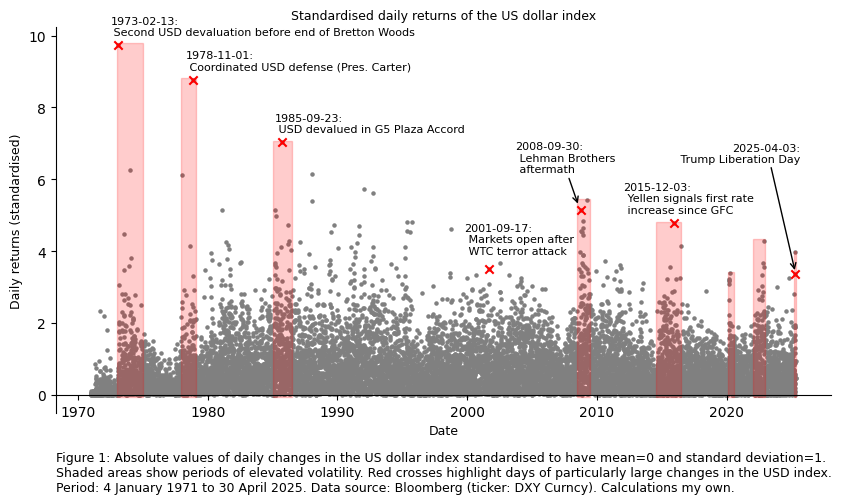

In [161]:
# Import packages
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

# Import monthly US dollar index data from CSV
dxy = pd.read_csv("dxy.csv")

# Convert to date
dxy["Dates"] = pd.to_datetime(dxy["Dates"], dayfirst=True).dt.date

# Convert to floats
dxy["DXY"] = dxy["DXY"].astype(float)

# Calculate arithmetic monthly returns
dxy["Rtns"] = dxy["DXY"].pct_change()

# Calculate absolute values of standardised daily changes
dxy["StdRtns"] = abs(dxy["Rtns"] - dxy["Rtns"].mean()) / dxy["Rtns"].std()

# Plot standardised returns
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(dxy["Dates"], dxy["StdRtns"], 5, "gray")
ax.set_title('Standardised daily returns of the US dollar index', fontsize=9)
ax.set_xlabel('Date', fontsize=9)
ax.set_ylabel('Daily returns (standardised)', fontsize=9)
ax.annotate(
    ('Figure 1: Absolute values of daily changes in the US dollar index '
     'standardised to have mean=0 and standard deviation=1. \n Shaded areas '
     'show periods of elevated volatility. Red crosses highlight days of '
     'particularly large changes in the USD index. \n Period: 4 January 1971 '
     'to 30 April 2025. Data source: Bloomberg (ticker: DXY Curncy). '
     'Calculations my own.'),
    xy=(0, -0.1),
    xycoords='axes fraction',
    ha='left',
    va='top',
    fontsize=9
)

# Move the spines
ax.spines['bottom'].set_position(('data', 0))  # x-axis crosses y=0
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_label_position('bottom')

# Mark highest values
idxLabels = [523, 1954, 3678, 7754, 9584, 11451, 13878]
desLabels = ["Second USD devaluation before end of Bretton Woods",
             "Coordinated USD defense (Pres. Carter)",
             "USD devalued in G5 Plaza Accord",
             "Markets open after \n WTC terror attack",
             "Lehman Brothers \n aftermath",
             "Yellen signals first rate \n increase since GFC",
             "Trump Liberation Day"];
offsetLabels = [[10, 28, 48, 80, 70, 100, 165], [7, 7, 7, 11, 27, 7, 80]]
alignLabels = ['left', 'left', 'left', 'left', 'left', 'left', 'right']

for i in range(len(idxLabels)):
    ax.scatter(
        dxy.loc[idxLabels[i], "Dates"],
        dxy.loc[idxLabels[i], "StdRtns"],
        marker="x",
        c="red"
    )
    labelText = f"{dxy.loc[idxLabels[i], 'Dates']}:\n {desLabels[i]}"
    ax.annotate(
        labelText,
        (idxLabels[i],
         dxy.loc[idxLabels[i], "StdRtns"]),
        textcoords="offset points",
        xytext=(offsetLabels[0][i], offsetLabels[1][i]),
        ha=alignLabels[i],
        fontsize=8
    )

# Highlight high-vol periods

# Bretton Woods 1973
ax.axvspan(datetime(1973, 1, 1), datetime(1974, 12, 31), ymin=0.04, ymax=0.96,
           color='red', alpha=0.2)

# High inflation, USD under pressure 1977-1978
ax.axvspan(datetime(1977, 12, 1), datetime(1979, 1, 31), ymin=0.04, ymax=0.87,
           color='red', alpha=0.2)

# Plaza accord 1985
ax.axvspan(datetime(1985, 1, 1), datetime(1986, 6, 30), ymin=0.04, ymax=0.705,
           color='red', alpha=0.2)

# Lehman 2008
ax.axvspan(datetime(2008, 6, 30), datetime(2009, 6, 30), ymin=0.04, ymax=0.555,
           color='red', alpha=0.2)
# Lehman 2008 arrow
ax.annotate(
    '',
    xy=(14100, 5.25),
    xytext=(13800, 6.1),
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1)
)

# Fed rate hike 2015
ax.axvspan(datetime(2014, 7, 31), datetime(2016, 6, 30), ymin=0.04, ymax=0.495,
           color='red', alpha=0.2)

# Covid-19 2020
ax.axvspan(datetime(2020, 2, 1), datetime(2020, 7, 31), ymin=0.04, ymax=0.365,
           color='red', alpha=0.2)

# Fight against inflation 2022
ax.axvspan(datetime(2022, 1, 1), datetime(2022, 12, 31), ymin=0.04, ymax=0.45,
           color='red', alpha=0.2)

# Trump Liberation Day 2025
ax.axvspan(datetime(2025, 3, 1), datetime(2025, 4, 30), ymin=0.04, ymax=0.42,
           color='red', alpha=0.2)
# Trump 2025 arrow
ax.annotate(
    '',
    xy=(20200, 3.4),
    xytext=(19500, 6.4),
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1)
)

# Show plot
plt.show()

The above illustration shows absolute value changes in the trade-weighted US dollar index in multiples of the data set's historical standard deviation. The maximum value comes in at 9.68 standard deviations on 13 February 1973 when, following negotiations with Germany and Japan, the US dollar was devalued for the second time since the 1971 Smithsonian agreement. To put this in perspective: According to scientific opinion, the universe is 13.8 billion years old. *Statistically* and under the assumption of standard normally distributed data, an event with a magnitude of 9.7 standard deviations is expected to occur with a probability of only 0.1% even over this long time period since the beginning of the universe. This makes apparent that a normal distribution is *not* a suitable measure for modelling prices – regardless of the central limit theorem.

Moving on to the present, the Trump administration's announcement of "reciprocal" tariffs in April 2025 caused elevated volatility in foreign exchange markets - but not historically high levels of volatility. The change in the US dollar index on "Liberation Day" was of order 3.4 standard deviations, well above the daily average but comfortably below previously observed extreme values. This was surpassed a week later by a 4 standard deviation event when Trump surprised markets by "pausing" the announced tariffs.

The "grouping" of volatility, also known as **volatility clustering** and approximated for selected periods by the shaded areas in figure 1, is a well-documented characteristic of volatility in financial time series data. The fear in today's environment, at least from the perspective of non-US investors, is that recent events have eroded trust in the US dollar, leading to persistently high volatility in currency markets and possibly an extended period of US dollar weakness. Volatility has abated as I write these lines in September 2025, but the US dollar has lost more than 10% already against its peers year-to-date.

### The currency flows, the reserve never stays the same
With this free adaptation of a quotation from the Roman emperor Marcus Aurelius – whose original words I have chosen as the title of this article – I enter into a brief discussion of the US dollar as the world's reserve currency. We might equally have invoked George Harrison ("All things must pass"), for at heart the point is the same: no system in human history has ever endured forever. (Of course, this is not meant to apply to my venerable employer, the Metzler banking house, which has thrived as a family-owned institution since 1674. Fingers crossed.)

But does this assertion truly apply to the US dollar? One could be forgiven for thinking that Donald Trump's administration itself is intent on undermining the reserve status of its own currency. After all, it has not stopped at trade tariffs and sudden sallies against America's partners: the independence of the US Federal Reserve has been openly questioned and even attacked, with members of its Board placed under pressure. Is a deliberate effort under way to weaken the dollar sustainably and to displace its central role within the global economic system? This question appears radical only at first sight:

**The issuance of a reserve currency is closely linked to current account deficits.** Demand from other nations for reserves compels the issuing country to expand its supply, with the result of widening its external deficit. This relationship is today commonly known as the **Triffin dilemma** – named after Robert Triffin, although it had previously been examined by Feliks Młynarski (Bordo and McCauley, 2017). Any refusal or inability to provide, or significant cut in the supply of, the reserve currency would undermine monetary stability and could even precipitate a global depression.

In short, there are sound reasons why nations might have little genuine interest in seeing their domestic currency assume the role of the world’s reserve currency. Contrary to popular belief, I argue, this reality will not be lost on the economies of both China and Europe. It is easy to imagine a world in which autarky and bilateral trade arrangements play a greater role again, without the need for *one* reserve currency.

Moreover, the so‑called **impossible trinity**, originating from the (probably independent but contemporaneous) work of IMF economists John Marcus Fleming and Robert Alexander Mundell, weighs even more heavily in the case of reserve currencies, imposing additional constraints on US monetary freedom. All of this is likely to be far more irksome to Donald Trump and his advisers than the superficial fact that the United States, as such, runs a deficit.

"But the US dollar can be wielded as a weapon," you might argue. My response is that the United States possesses far more instruments in its arsenal than just its military and the dollar to project its interests internationally. Equally significant, in my view, is the systemic dependence on American services. This reliance is glaring in today's networked world – above all in Europe, where local alternatives have so far failed to take root. The key payment processors, credit card companies, software providers and cloud operators are overwhelmingly American. Such dependence is structural: in a world so digitally interconnected, the mere flick of a switch could bring Europe to a standstill.

This alarmist notion is merely meant to underscore the point that **the United States does not need to cling to the reserve‑currency status of the dollar in order to preserve its power**. If the current administration's focus is increasingly on national interest and greater latitude in monetary policy, then this scenario must be considered.

Even so, the actions of the Trump administration so far have *already* weighed negatively on the dollar. Should the move away from the dollar and US markets continue in light of political instability, uncertainty will rise further, volatility could flare up again, and the dollar may depreciate far more sharply than it has so far.

### Prepare for US dollar weakness – even if it is not your main scenario
The essence for investors with US dollar exposures is this: address your currency risks *today*, not months or years from now simply because other asset‑allocation decisions appear more pressing. Consult currency specialists and review your portfolio with them for hidden exposures and foreign exchange dynamics. Establish a risk‑management process that is flexible enough to adapt to change and robust across scenarios.

A look at purchasing power parity shows that the US dollar has been overvalued for quite some time. By our estimates, a fair valuation under this measure would imply an EUR/USD exchange rate of 1.40 – or even higher. If that feels remote, recall the not‑so‑distant past: between 2002 and 2008 the rate climbed from below 0.90 (with the dollar overvalued) to 1.60 (fairly valued, later verging on undervalued). Another marked appreciation of the euro against the dollar from current levels is therefore not an unrealistic scenario. Whether it is the *most likely* outcome I cannot say – but it is a risk that must be taken seriously.

### References
Bordo, Michael D., and Robert N. McCauley (2017). Triffin: dilemma or myth? *BIS Working Papers*, no. 684.

Ghosh, Atish Rex (2021). From the History Books: The Rethinking of the International Monetary System. *IMF website*, https://www.imf.org/en/Blogs/Articles/2021/08/16/from-the-history-books-the-rethinking-of-the-international-monetary-system. Last accessed: 12 September 2025.

### Image credit
The cover image was created using OpenAI's algorithm.

### Open source
Everything I publish here is freely accessible under the MIT licence. I strive to credit all external sources and hope you will do likewise when using my work. While I share my research and code openly to foster transparency and collaboration, I cannot release underlying data bound by commercial licence agreements. You find the calculations and source codes for this article in my GitHub repository at https://github.com/dmueller-dev/quant-research.

### Disclaimer
Everything I write is my own personal opinion and does not necessarily reflect the opinion of my employer. Nothing I write is investment advice. You invest at your own risk. Past performance is no indicator of future performance.